C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\marginal_likelihoods.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[INFO] Initializing Triceratops validation pipeline for TOI 7701.01 (122522333)
----------------------------------------------------------------------
[INFO] Retrieving Target Pixel Files and pipeline apertures...
[INFO] Processing Sector 97...
[INFO] Aperture successfully extracted.
[INFO] Generating aperture field plot...


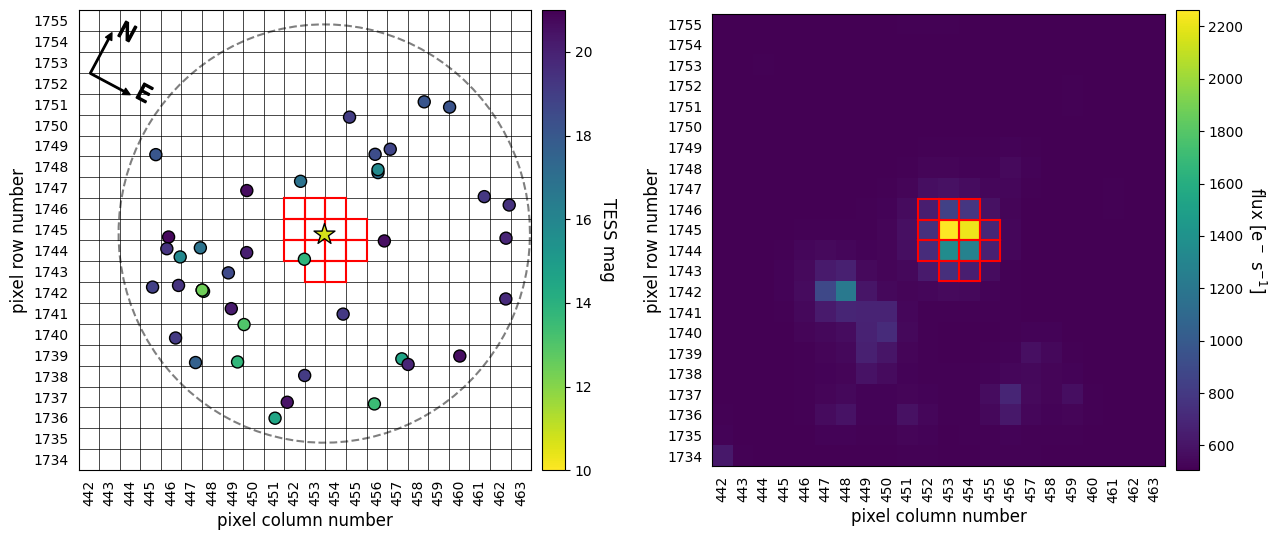

[INFO] Successfully assembled apertures for 1 sector(s).

[INFO] Calculating expected transit depths for nearby stars...

[INFO] Initiating MCMC statistical engine (this may take several minutes)...
[INFO] Loading phase-folded light curve: TOI7701.01_LC_folded_raw_sap.csv
[INFO] Data cropped and binned to 250 cadences within the transit window.
[INFO] Executing calc_probs() in parallel mode...
griz mags: nan nan nan nan
Calculating TP scenario probability for 122522333.
Calculating EB and EBx2P scenario probabilities for 122522333.
Z, Teff, logg: 0.0 6250 4.0
Calculating PTP scenario probability for 122522333.
Calculating PEB and PEBx2P scenario probabilities for 122522333.
Calculating STP scenario probability for 122522333.
Calculating SEB and SEBx2P scenario probabilities for 122522333.
Calculating DTP scenario probability for 122522333.
Calculating DEB and DEBx2P scenario probabilities for 122522333.
Calculating BTP scenario probability for 122522333.
Calculating BEB and BEBx2P scen

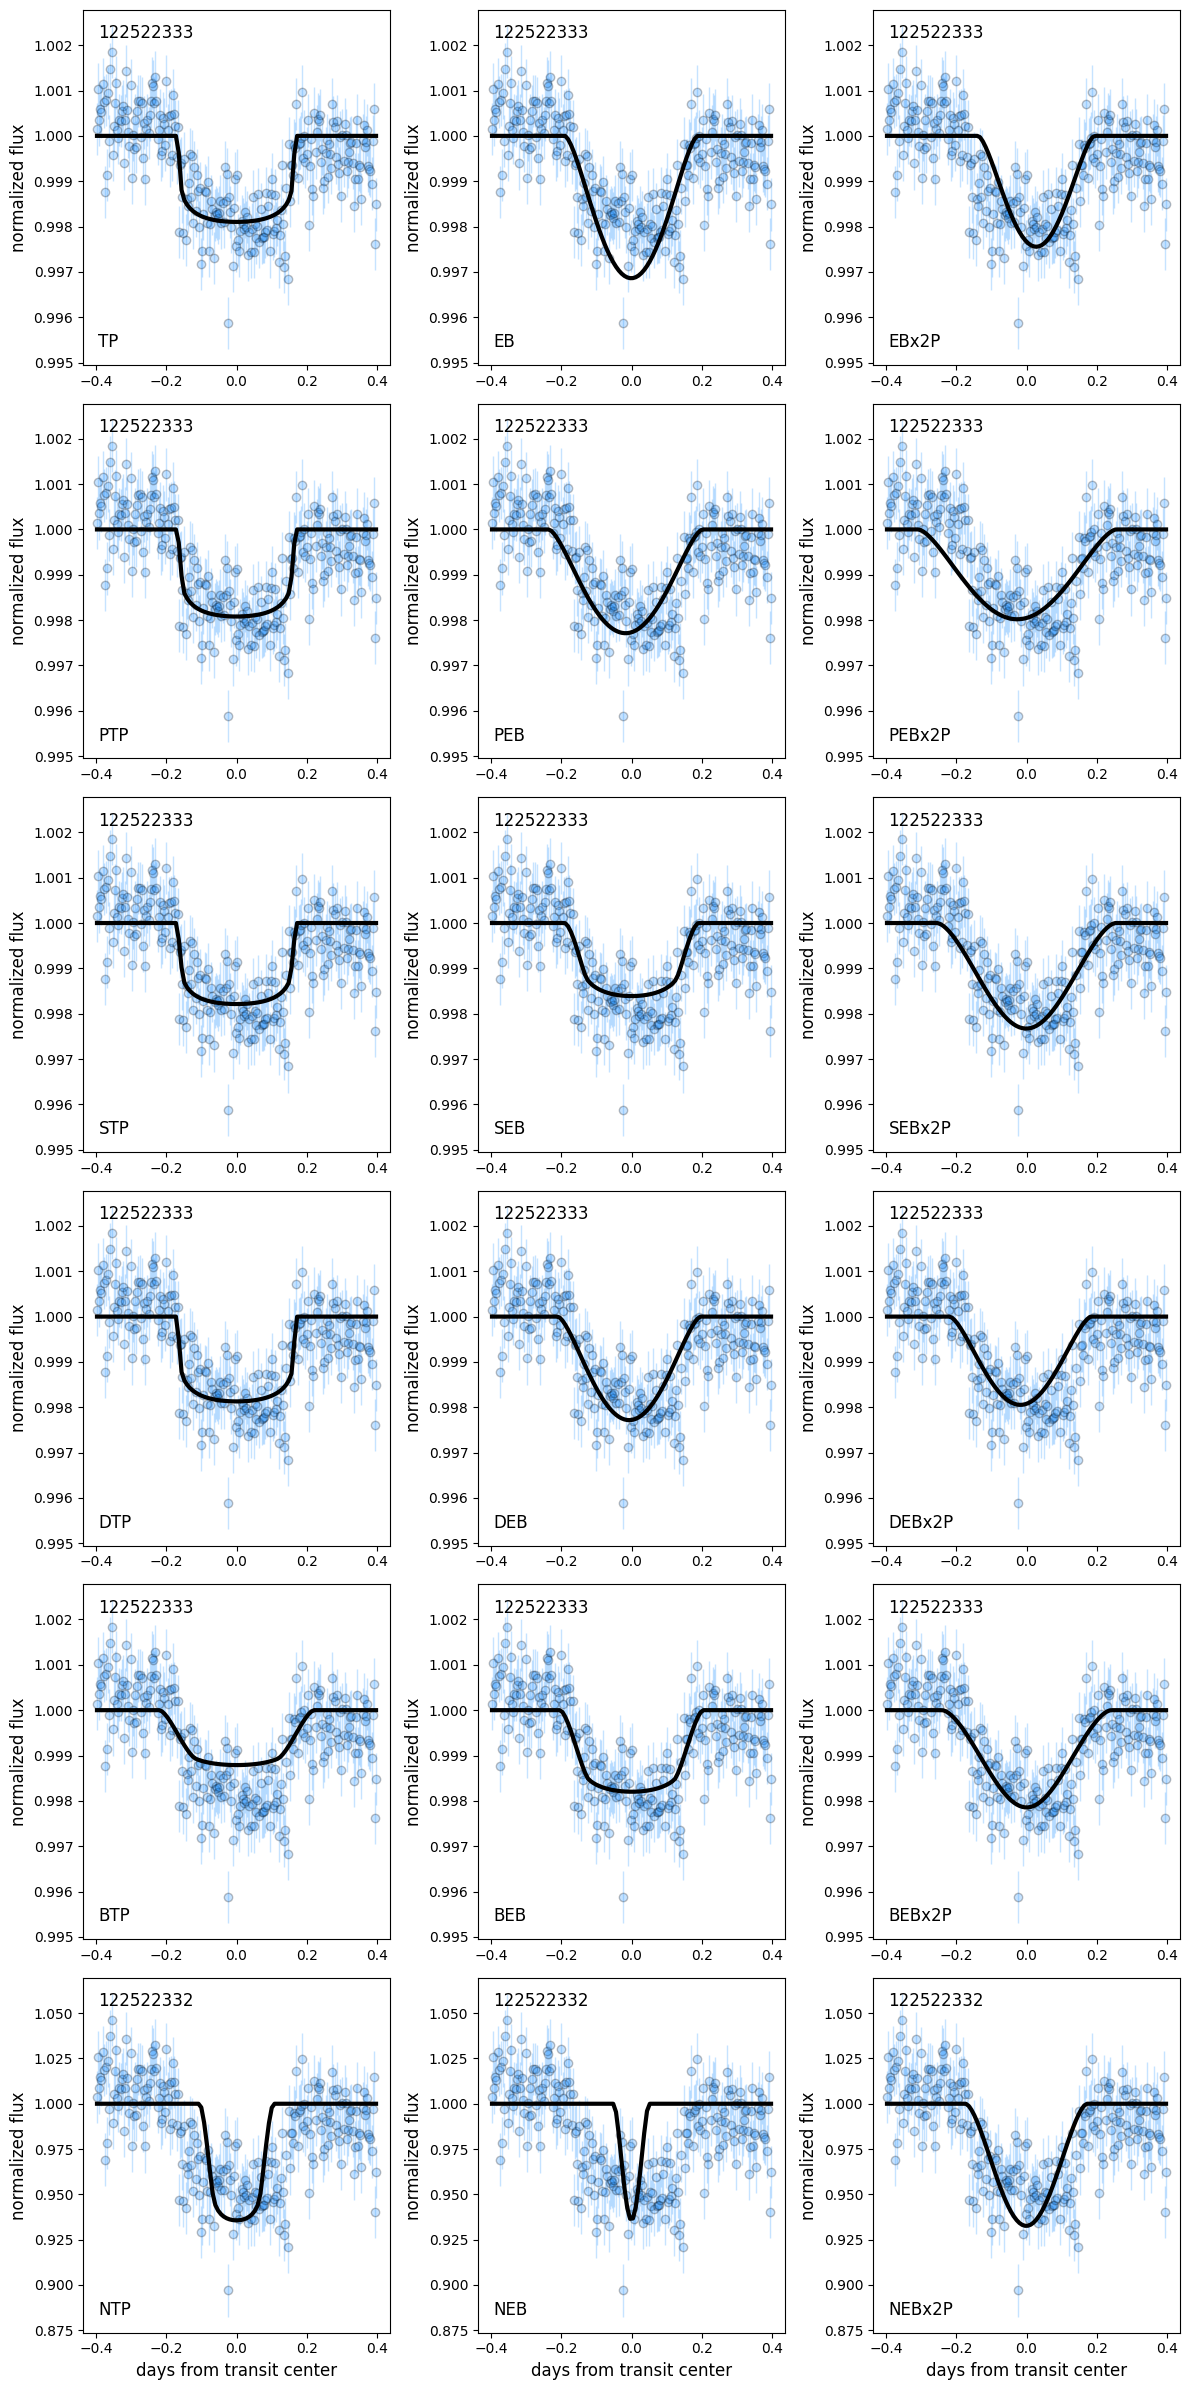


[INFO] Pipeline complete.


In [ ]:
"""
03_triceratops_validation_TOI7701.py
=============================================================================
STATISTICAL VALIDATION: TRICERATOPS BAYESIAN FPP ANALYSIS
=============================================================================

Computes the False Positive Probability (FPP) and Nearby False Positive
Probability (NFPP) for TOI 7701.01 (TIC 122522333) using the triceratops
tool. Ingests un-detrended ("natural") phase-folded light curve data to
evaluate astrophysical false positive scenarios (e.g., eclipsing binaries,
background eclipsing binaries).

TARGET:
    TIC ID        : 122522333
    TOI           : 7701.01
    Sectors       : 97
    Transit Depth : 2417 ppm
    Period        : 20.616076 days

OUTPUT:
    - Diagnostic field map and aperture plots.
    - Fitted scenario light curve plots (TP, EB, BEB, etc.).
    - Console report: FPP and NFPP scores, star field table, and
      bayesian probability breakdown.

DEPENDENCIES:
    numpy, pandas, lightkurve, matplotlib, triceratops, os

REFERENCES:
    Giacalone et al. (2021), AJ, 161, 24
"""

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt
import triceratops.triceratops as tr
import os
import warnings
import requests
import urllib3
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

old_request = requests.Session.request

def patched_request(self, method, url, **kwargs):
    kwargs['verify'] = False  
    return old_request(self, method, url, **kwargs)

requests.Session.request = patched_request

os.environ['CURL_CA_BUNDLE'] = ''
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
# ---------------------------------------------------

warnings.simplefilter('ignore')


# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
TIC_ID         = 122522333  
SECTORS        = np.array([97])  

# Parameters extracted from the detection pipeline (BLS)
TRANSIT_DEPTH  = 0.002417      # Decimal equivalent of 2417 ppm
ORBITAL_PERIOD = 20.616076     # days

# The raw, un-detrended folded data exported in step 01
INPUT_FILE     = "TOI7701.01_LC_folded_raw.csv" 

print(f"[INFO] Initializing Triceratops validation pipeline for TOI 7701.01 ({TIC_ID})")
print("-" * 70)

target = tr.target(ID=TIC_ID, sectors=SECTORS)

# ---------------------------------------------------------------------------
# APERTURE RETRIEVAL AND FIELD VISUALIZATION
# ---------------------------------------------------------------------------
print("[INFO] Retrieving Target Pixel Files and pipeline apertures...")
apertures_list = []  

for sector_num in SECTORS:
    try:
        print(f"[INFO] Processing Sector {sector_num}...")
        search_sec = lk.search_targetpixelfile(f"TIC {TIC_ID}", sector=sector_num, author="SPOC")
        
        if len(search_sec) == 0: 
            search_sec = lk.search_targetpixelfile(f"TIC {TIC_ID}", sector=sector_num, author="TESS-SPOC")
            
        tpf_sec  = search_sec.download()
        mask_sec = tpf_sec.pipeline_mask
        ap_sec   = np.c_[tpf_sec.column + np.where(mask_sec)[1], tpf_sec.row + np.where(mask_sec)[0]]
        
        apertures_list.append(ap_sec)
        print(f"[INFO] Aperture successfully extracted.")

        # Plot field for the first available sector to visualize contaminants
        if sector_num == SECTORS[0]:
            print("[INFO] Generating aperture field plot...")
            target.plot_field(sector=sector_num, ap_pixels=ap_sec)
            
    except Exception as e:
        print(f"[WARNING] Could not retrieve aperture for sector {sector_num}: {e}")
        apertures_list.append(np.array([]))

all_apertures = np.array(apertures_list, dtype=object)  
print(f"[INFO] Successfully assembled apertures for {len(all_apertures)} sector(s).")

# ---------------------------------------------------------------------------
# NEIGHBORING STAR DEPTH CALCULATION
# ---------------------------------------------------------------------------
print("\n[INFO] Calculating expected transit depths for nearby stars...")
target.calc_depths(tdepth=TRANSIT_DEPTH, all_ap_pixels=all_apertures)

# ---------------------------------------------------------------------------
# DATA INGESTION AND BAYESIAN FPP CALCULATION
# ---------------------------------------------------------------------------
print("\n[INFO] Initiating MCMC statistical engine (this may take several minutes)...")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"[ERROR] Input file not found: {INPUT_FILE}. "
                            "Ensure it is located in the working directory.")

print(f"[INFO] Loading phase-folded light curve: {INPUT_FILE}")
lc_data = pd.read_csv(INPUT_FILE, header=None)

time     = lc_data[0].values
flux     = lc_data[1].values
flux_err = lc_data[2].values

# Strategic cropping: Focus strictly on the transit window and local baseline
# Transit duration is ~7.8h. Expanding window to +/- 0.4 days (~9.6h)
mask_zoom     = np.abs(time) < 0.4
time_zoom     = time[mask_zoom]
flux_zoom     = flux[mask_zoom]
flux_err_zoom = flux_err[mask_zoom]

# ---- CORRECTION: LOCAL RE-NORMALIZATION ----
# The transit lasts 7.08 hours. 
# We define "out-of-transit" (OOT) as data beyond +/- 0.20 days.
oot_mask = np.abs(time_zoom) > 0.20
local_baseline = np.median(flux_zoom[oot_mask])

# Center the local flux so the baseline is exactly 1.0
flux_zoom = flux_zoom / local_baseline
flux_err_zoom = flux_err_zoom / local_baseline
# -------------------------------------------

# Apply binning to reduce computational load and smooth out-of-transit noise
lc_binsize = (time_zoom.max() - time_zoom.min()) / 250
lc_binned  = lk.LightCurve(time=time_zoom, flux=flux_zoom, flux_err=flux_err_zoom).bin(time_bin_size=lc_binsize).remove_nans()

print(f"[INFO] Data cropped and binned to {len(lc_binned)} cadences within the transit window.")
print("[INFO] Executing calc_probs() in parallel mode...")

target.calc_probs(
    time=lc_binned.time.value, 
    flux_0=lc_binned.flux.value, 
    flux_err_0=np.mean(lc_binned.flux_err.value), 
    P_orb=ORBITAL_PERIOD,
    parallel=True  
)

# ---------------------------------------------------------------------------
# RESULTS AND DIAGNOSTICS REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"TRICERATOPS VALIDATION REPORT — TOI 7701.01 ({TIC_ID})")
print("=" * 70)
print(f" FPP  (False Positive Prob)        : {target.FPP:.8f}")
print(f" NFPP (Nearby False Positive Prob) : {target.NFPP:.8f}")
print("-" * 70)

# Interpretation based on rigorous scientific criteria (Giacalone et al. 2021)
if target.FPP < 0.015 and target.NFPP < 0.001:
    print(" [RESULT] STATUS: VALIDATED PLANET CANDIDATE")
    print("          (FPP < 1.5% and NFPP < 0.1% thresholds met).")
elif target.FPP < 0.5:
    print(" [RESULT] STATUS: LIKELY PLANET CANDIDATE")
    print("          (FPP < 50%. Planet scenario favored over EB or BEB).")
else:
    print(" [WARNING] STATUS: PROBABLE FALSE POSITIVE")
    print("           (FPP > 50%. High probability of EB or BEB contamination).")

print("=" * 70)

print("\n[INFO] Star Field Analysis (Sources within aperture):")
print(target.stars)

print("\n[INFO] Bayesian Probability Breakdown:")
print(target.probs)

# ---------------------------------------------------------------------------
# ASTROPHYSICAL SCENARIO PLOTS
# ---------------------------------------------------------------------------
print("\n[INFO] Generating adjusted astrophysical scenario models...")

if hasattr(target, 'probs') and target.probs is not None and len(target.probs) > 0:
    target.plot_fits(
        time=lc_binned.time.value, 
        flux_0=lc_binned.flux.value, 
        flux_err_0=np.mean(lc_binned.flux_err.value)
    )
    plt.show()
else:
    print("[WARNING] Could not generate plots (probability array is empty).")

print("\n[INFO] Pipeline complete.")

C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\marginal_likelihoods.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[INFO] Initializing Robust Triceratops validation pipeline for TOI 7701.01 (122522333)
----------------------------------------------------------------------
[INFO] Retrieving Target Pixel Files and pipeline apertures...
[INFO] Processing Sector 97...
[INFO] Aperture successfully extracted.
[INFO] Generating aperture field plot...


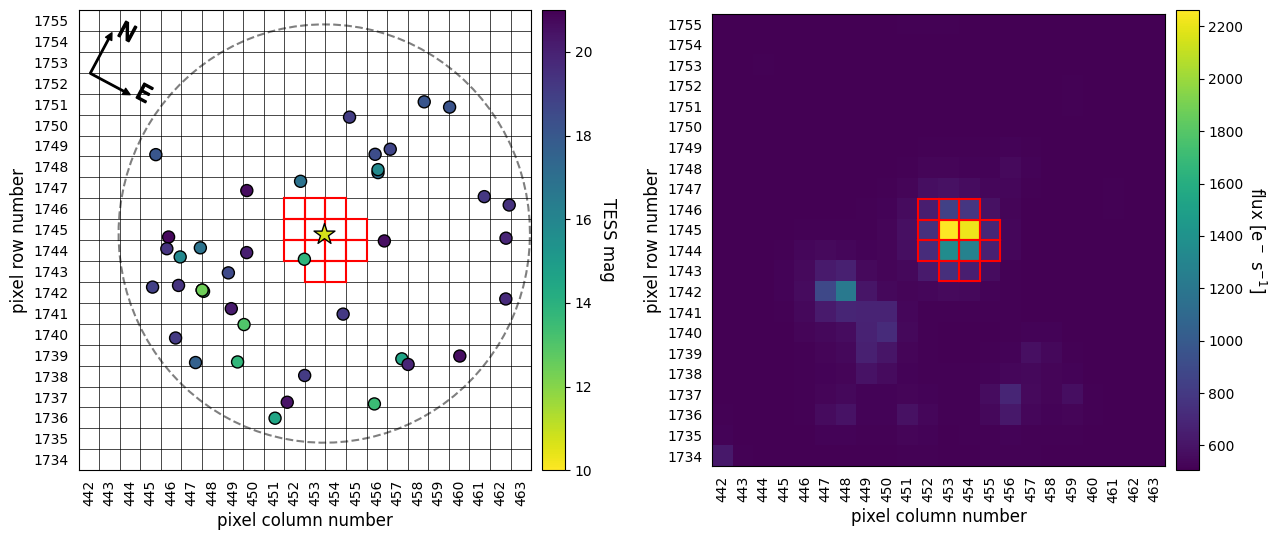

[INFO] Successfully assembled apertures for 1 sector(s).

[INFO] Calculating expected transit depths for nearby stars...

[INFO] Preparing phase-folded light curve data...
[INFO] Loading phase-folded light curve: TOI7701.01_LC_folded_raw_sap.csv
[INFO] Data cropped, locally normalized, and binned to 250 cadences.

[INFO] EXECUTING 20 MCMC ITERATIONS (Stability Test)...
       This process is computationally intensive. Please wait.
       [INFO] Calculating Iteration 1/20...
griz mags: nan nan nan nan
Calculating TP scenario probability for 122522333.
Calculating EB and EBx2P scenario probabilities for 122522333.
Z, Teff, logg: 0.0 6250 4.0
Calculating PTP scenario probability for 122522333.
Calculating PEB and PEBx2P scenario probabilities for 122522333.
Calculating STP scenario probability for 122522333.
Calculating SEB and SEBx2P scenario probabilities for 122522333.
Calculating DTP scenario probability for 122522333.
Calculating DEB and DEBx2P scenario probabilities for 122522333.
C

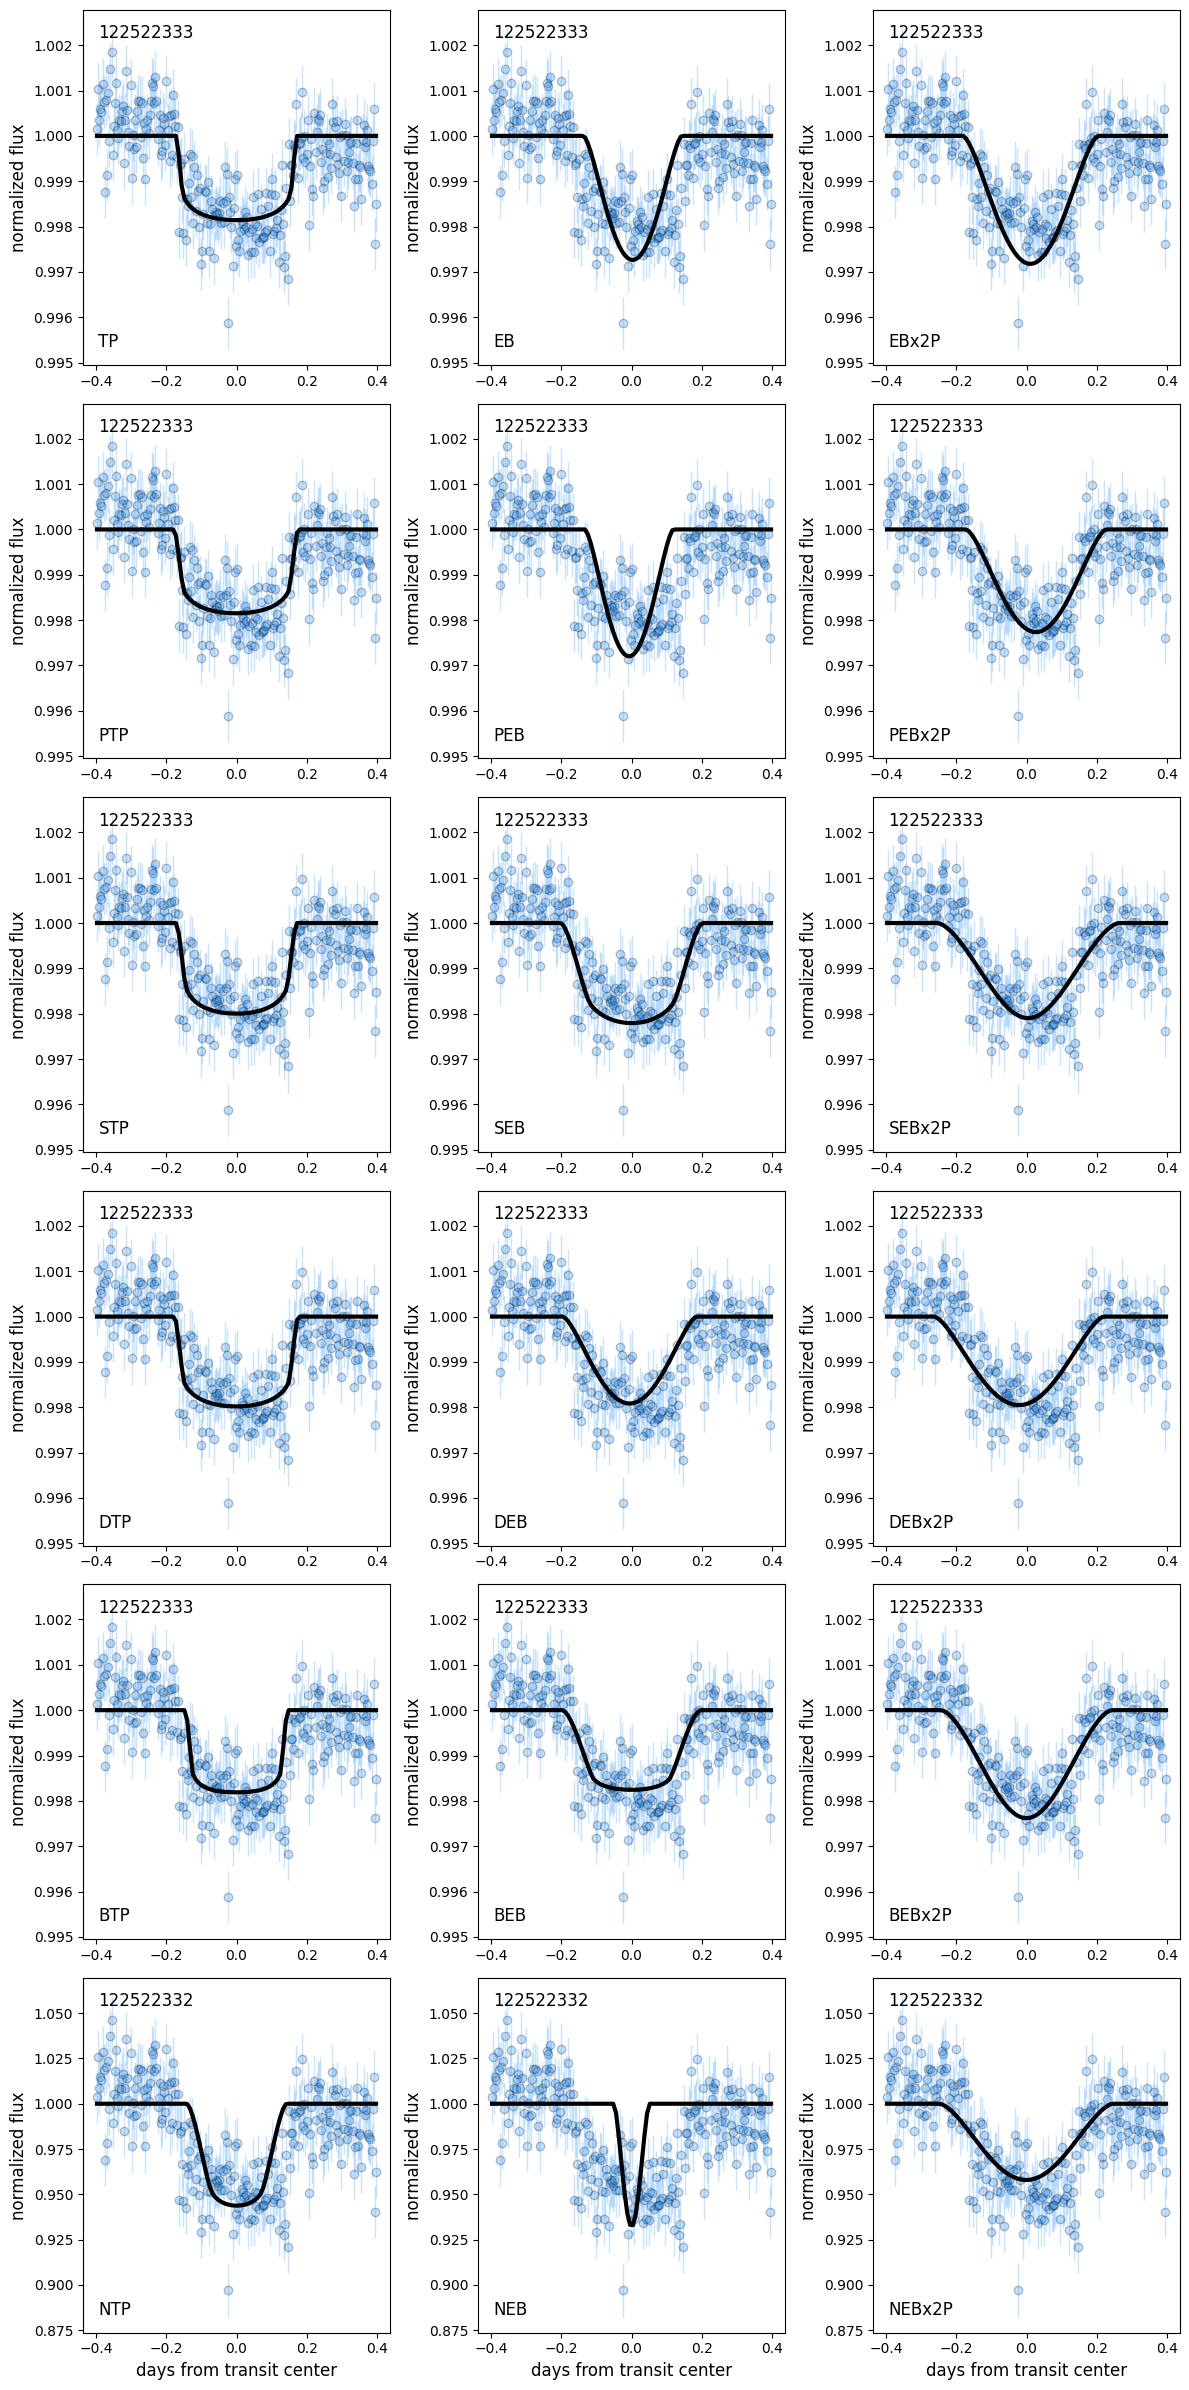


[INFO] Pipeline complete.


In [ ]:
"""
=============================================================================
03_triceratops_validation_multi_iter_TOI7701.py
=============================================================================
ROBUST STATISTICAL VALIDATION: MULTI-ITERATION TRICERATOPS MCMC
=============================================================================

Computes the False Positive Probability (FPP) and Nearby False Positive
Probability (NFPP) for TOI 7701.01 (TIC 122522333) by ingesting un-detrended 
("natural") phase-folded data. 

Features:
    - Native SSL patches for stable MAST/ExoFOP querying.
    - SPOC pipeline aperture extraction for Sector 97.
    - Local baseline re-normalization to isolate the transit depth.
    - Stability test: Executes the MCMC engine N times to extract absolute 
      statistical parameters (Mean, Min, Max, Standard Deviation, Variance).

TARGET:
    TIC ID        : 122522333
    TOI           : 7701.01
    Sectors       : 97
    Transit Depth : 2417 ppm (SAP)
    Period        : 20.616076 days

OUTPUT:
    - Diagnostic field map and aperture plots.
    - Fitted scenario light curve plots (from the final iteration).
    - Console report: Multi-iteration global statistics and verdict.

DEPENDENCIES:
    numpy, pandas, lightkurve, matplotlib, triceratops, os, requests

REFERENCES:
    Giacalone et al. (2021), AJ, 161, 24
=============================================================================
"""

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt
import triceratops.triceratops as tr
import os
import warnings
import requests
import urllib3
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

old_request = requests.Session.request

def patched_request(self, method, url, **kwargs):
    kwargs['verify'] = False  
    return old_request(self, method, url, **kwargs)

requests.Session.request = patched_request

os.environ['CURL_CA_BUNDLE'] = ''
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
# ---------------------------------------------------

warnings.simplefilter('ignore')


# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
TIC_ID         = 122522333  
SECTORS        = np.array([97])  

# Parameters extracted from the detection pipeline (BLS)
TRANSIT_DEPTH  = 0.002417      # Decimal equivalent of 2417 ppm
ORBITAL_PERIOD = 20.616076     # days

# The raw, un-detrended folded data exported in step 01
INPUT_FILE     = "TOI7701.01_LC_folded_raw.csv" 
ITERATIONS     = 20            # Number of MCMC runs for the stability test

print(f"[INFO] Initializing Robust Triceratops validation pipeline for TOI 7701.01 ({TIC_ID})")
print("-" * 70)

target = tr.target(ID=TIC_ID, sectors=SECTORS)

# ---------------------------------------------------------------------------
# APERTURE RETRIEVAL AND FIELD VISUALIZATION
# ---------------------------------------------------------------------------
print("[INFO] Retrieving Target Pixel Files and pipeline apertures...")
apertures_list = []  

for sector_num in SECTORS:
    try:
        print(f"[INFO] Processing Sector {sector_num}...")
        search_sec = lk.search_targetpixelfile(f"TIC {TIC_ID}", sector=sector_num, author="SPOC")
        
        if len(search_sec) == 0: 
            search_sec = lk.search_targetpixelfile(f"TIC {TIC_ID}", sector=sector_num, author="TESS-SPOC")
            
        tpf_sec  = search_sec.download()
        mask_sec = tpf_sec.pipeline_mask
        ap_sec   = np.c_[tpf_sec.column + np.where(mask_sec)[1], tpf_sec.row + np.where(mask_sec)[0]]
        
        apertures_list.append(ap_sec)
        print(f"[INFO] Aperture successfully extracted.")

        # Plot field for the first available sector to visualize contaminants
        if sector_num == SECTORS[0]:
            print("[INFO] Generating aperture field plot...")
            target.plot_field(sector=sector_num, ap_pixels=ap_sec)
            
    except Exception as e:
        print(f"[WARNING] Could not retrieve aperture for sector {sector_num}: {e}")
        apertures_list.append(np.array([]))

all_apertures = np.array(apertures_list, dtype=object)  
print(f"[INFO] Successfully assembled apertures for {len(all_apertures)} sector(s).")

# ---------------------------------------------------------------------------
# NEIGHBORING STAR DEPTH CALCULATION
# ---------------------------------------------------------------------------
print("\n[INFO] Calculating expected transit depths for nearby stars...")
target.calc_depths(tdepth=TRANSIT_DEPTH, all_ap_pixels=all_apertures)

# ---------------------------------------------------------------------------
# DATA PREPARATION & LOCAL RE-NORMALIZATION
# ---------------------------------------------------------------------------
print("\n[INFO] Preparing phase-folded light curve data...")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"[ERROR] Input file not found: {INPUT_FILE}. "
                            "Ensure it is located in the working directory.")

print(f"[INFO] Loading phase-folded light curve: {INPUT_FILE}")
lc_data = pd.read_csv(INPUT_FILE, header=None)

time     = lc_data[0].values
flux     = lc_data[1].values
flux_err = lc_data[2].values

# Strategic cropping: Focus strictly on the transit window and local baseline
# Transit duration is ~7.08h. Expanding window to +/- 0.4 days (~9.6h)
mask_zoom     = np.abs(time) < 0.4
time_zoom     = time[mask_zoom]
flux_zoom     = flux[mask_zoom]
flux_err_zoom = flux_err[mask_zoom]

# ---- CORRECTION: LOCAL RE-NORMALIZATION ----
# The transit lasts 7.08 hours. 
# We define "out-of-transit" (OOT) as data beyond +/- 0.20 days.
oot_mask = np.abs(time_zoom) > 0.20
local_baseline = np.median(flux_zoom[oot_mask])

# Center the local flux so the baseline is exactly 1.0
flux_zoom = flux_zoom / local_baseline
flux_err_zoom = flux_err_zoom / local_baseline
# -------------------------------------------

# Apply binning to reduce computational load and smooth out-of-transit noise
lc_binsize = (time_zoom.max() - time_zoom.min()) / 250
lc_binned  = lk.LightCurve(time=time_zoom, flux=flux_zoom, flux_err=flux_err_zoom).bin(time_bin_size=lc_binsize).remove_nans()

print(f"[INFO] Data cropped, locally normalized, and binned to {len(lc_binned)} cadences.")

# ---------------------------------------------------------------------------
# MULTI-ITERATION BAYESIAN FPP CALCULATION
# ---------------------------------------------------------------------------
print(f"\n[INFO] EXECUTING {ITERATIONS} MCMC ITERATIONS (Stability Test)...")
print("       This process is computationally intensive. Please wait.")

fpp_history  = []
nfpp_history = []

for i in range(ITERATIONS):
    print(f"       [INFO] Calculating Iteration {i+1}/{ITERATIONS}...")
    target.calc_probs(
        time=lc_binned.time.value, 
        flux_0=lc_binned.flux.value, 
        flux_err_0=np.mean(lc_binned.flux_err.value), 
        P_orb=ORBITAL_PERIOD,
        parallel=True 
    )
    fpp_history.append(target.FPP)
    nfpp_history.append(target.NFPP)

# Convert to Numpy arrays for rapid statistical operations
arr_fpp  = np.array(fpp_history)
arr_nfpp = np.array(nfpp_history)

# ---------------------------------------------------------------------------
# DETAILED STATISTICS AND REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"GLOBAL STATISTICAL RESULTS — TOI 7701.01 (N = {ITERATIONS})")
print("=" * 70)

# FPP Statistics
fpp_mean = np.mean(arr_fpp)
fpp_std  = np.std(arr_fpp)
fpp_min  = np.min(arr_fpp)
fpp_max  = np.max(arr_fpp)
fpp_var  = np.var(arr_fpp)

print("[RESULT] FALSE POSITIVE PROBABILITY (FPP):")
print(f"         Mean      : {fpp_mean:.8f}")
print(f"         Std Dev   : {fpp_std:.8f}")
print(f"         Minimum   : {fpp_min:.8f}")
print(f"         Maximum   : {fpp_max:.8f}")
print(f"         Variance  : {fpp_var:.10e}")
print("-" * 70)

# NFPP Statistics
nfpp_mean = np.mean(arr_nfpp)
nfpp_std  = np.std(arr_nfpp)
nfpp_min  = np.min(arr_nfpp)
nfpp_max  = np.max(arr_nfpp)
nfpp_var  = np.var(arr_nfpp)

print("[RESULT] NEARBY FALSE POSITIVE PROBABILITY (NFPP):")
print(f"         Mean      : {nfpp_mean:.8f}")
print(f"         Std Dev   : {nfpp_std:.8f}")
print(f"         Minimum   : {nfpp_min:.8f}")
print(f"         Maximum   : {nfpp_max:.8f}")
print(f"         Variance  : {nfpp_var:.10e}")
print("=" * 70)

# Scientific interpretation based on mean values
print("\n[INFO] SCIENTIFIC VERDICT:")

if fpp_mean < 0.015 and nfpp_mean < 0.001:
    print(" [RESULT] STATUS: VALIDATED PLANET CANDIDATE (Mean FPP < 1.5%)")
    print(f"          Incredible stability. Mean FPP: {fpp_mean*100:.3f}% | Mean NFPP: {nfpp_mean*100:.3f}%")
    
    if fpp_max >= 0.015:
        print(f"          (Note: An isolated MCMC iteration reached {fpp_max*100:.2f}%, but the mean remains robust).")
        
    print("          This candidate is statistically validated and ready for publication.")

elif fpp_mean < 0.5:
    print(f" [WARNING] STATUS: LIKELY PLANET CANDIDATE (Mean FPP: {fpp_mean*100:.2f}%)")
    print("           The planet scenario is favored over eclipsing binaries or blended events.")
else:
    print(" [ERROR] STATUS: PROBABLE FALSE POSITIVE")
    print("         The mean probabilities strongly indicate background contamination or non-planetary scenarios.")

print("=" * 70)

print("\n[INFO] Star Field Analysis (Sources within aperture for the final iteration):")
print(target.stars)

# ---------------------------------------------------------------------------
# ASTROPHYSICAL SCENARIO PLOTS (Based on the final iteration)
# ---------------------------------------------------------------------------
print("\n[INFO] Generating best-fit scenario plots (from final MCMC iteration)...")

if hasattr(target, 'probs') and target.probs is not None and len(target.probs) > 0:
    target.plot_fits(
        time=lc_binned.time.value, 
        flux_0=lc_binned.flux.value, 
        flux_err_0=np.mean(lc_binned.flux_err.value)
    )
    plt.show()
else:
    print("[WARNING] Could not generate plots (probability array is empty).")

print("\n[INFO] Pipeline complete.")